In [8]:
#####################################################
# Imports and Simulation IO
#####################################################

import os
from MDToolkit.data.objects import Topology, Frame, Simulation, LAMMPS_CustomDump_Reader, MultiSimulation
from MDToolkit.utils.structure_file_utils import create_elements_dictionary
from MDToolkit.analysis.current import ion_translocation, ion_translocations_to_current
from MDToolkit.data.misc_objects import  BoxVolume, CylinderVolume
from MDToolkit.IO.read_file import read_lammps_log_file

ensemble = 10

file_root_dir = "/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/"

times = [5, 10, 15]

filepaths = [os.path.join(file_root_dir + f"v{ensemble}/", f"kcl_mos2_prod_{time}ns_run{ensemble}.out") for time in times]

type_mapping = {
    1 : "Mo",
    2 : "S",
    3 : "Cl",
    4 : "H",
    5 : "K",
    6 : "O"
}

charges_dict = {
    1 : 1.1800,
    2 : -0.5900,
    3 : -1.0,
    4 : 0.4238,
    5 : 1.0,
    6 : -0.8476
}

ion_spcs = ["K", "Cl"]

topol = Topology(type_mapping, elements_dict = create_elements_dictionary(), charges_dict = charges_dict)

# simulations = [Simulation(filepath, topol, LAMMPS_CustomDump_Reader) for filepath in filepaths]
simulation = MultiSimulation(filepaths, topol, LAMMPS_CustomDump_Reader)

In [9]:
#####################################################
# Translocations
#####################################################

v1 = BoxVolume([-39.05, -26, -25], [-4, 26, 25])
v_trans = CylinderVolume([-4.0, 0.0, 0.0], [4.0, 0.0, 0.0], radius = 4.5)
v2 = BoxVolume([4, -26, -25], [39.015, 26, 25])

# translocation_results = [ion_translocation(simulation, ion_spcs, v1, v_trans, v2) for simulation in simulations]

translocation_results = [ion_translocation(simulation, ion_spcs, v1, v_trans, v2)]

  0%|          | 0/15003 [00:00<?, ?it/s]

In [10]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import matplotlib.pyplot as plt

def plot_current(results):
    '''
    Plot ionic current vs time.
    '''

    timesteps = results["timesteps"]

    plt.figure(figsize=(7, 4.5))

    plt.plot(
        timesteps,
        results["current"],
        linewidth=2.5,
        label="Savitzky-Golay Derivative"
    )

    plt.xlabel("Timestep")
    plt.ylabel("Current")

    plt.title("Ionic Current")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()


def plot_current_vs_field(results, log_df):
    '''
    Plot ionic current vs electric field.

    The electric field is taken only at the timesteps for which
    current data exist.
    '''

    current_steps = np.asarray(results["timesteps"])

    log_steps = log_df["Step"].to_numpy()
    log_field = log_df["v_ef_x"].to_numpy()

    idx = np.searchsorted(log_steps, current_steps)

    if np.any(idx >= len(log_steps)) or not np.all(log_steps[idx] == current_steps):
        raise ValueError("Some current timesteps were not found in the log file.")

    electric_field = log_field[idx]

    plt.figure(figsize=(7, 4.5))

    plt.plot(
        electric_field,
        results["current"],
        linewidth=2.5
    )

    plt.xlabel(r"Electric Field (V/$\mathrm{\AA}$)")
    plt.ylabel("Current")

    plt.title("Ionic Current")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.tight_layout()

    plt.show()


def plot_cumulative_charge_translocation(results):
    '''
    Plot cumulative charge translocation vs time.
    '''

    timesteps = results["timesteps"]

    plt.figure(figsize=(7, 4.5))

    plt.scatter(
        timesteps,
        results["cumulative_charge_translocation"],
        s=20,
        alpha=0.1,
        label="Mean Translocation"
    )

    plt.plot(
        timesteps,
        results["smoothed_cumulative_charge_translocation"],
        linewidth=2.5,
        label="Savitzky-Golay Fit",
        color = "purple"
    )

    plt.xlabel("Timestep")
    plt.ylabel("Cumulative Charge Translocation (e)")

    plt.title("Cumulative Charge Translocation")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()

In [11]:
ionic_current = ion_translocations_to_current(translocation_results, window_length = 2000)

In [12]:
import pandas as pd 

log_file_dir = f"/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/v2/"
log_file_names = ["efield_prod_job_output.o3322604", "efield_prod_job_output.o3335421", "efield_prod_job_output.o3346834"]

log_file_paths = [os.path.join(log_file_dir, log_file_name) for log_file_name in log_file_names]

log_dfs = [read_lammps_log_file(log_file_path) for log_file_path in log_file_paths]

log_df = pd.concat(log_dfs, ignore_index=True)

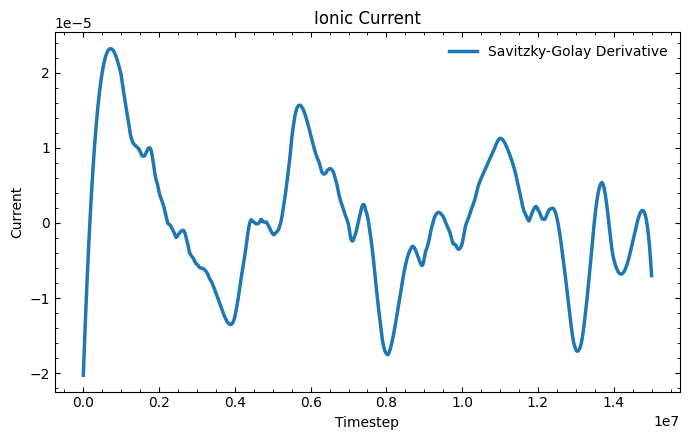

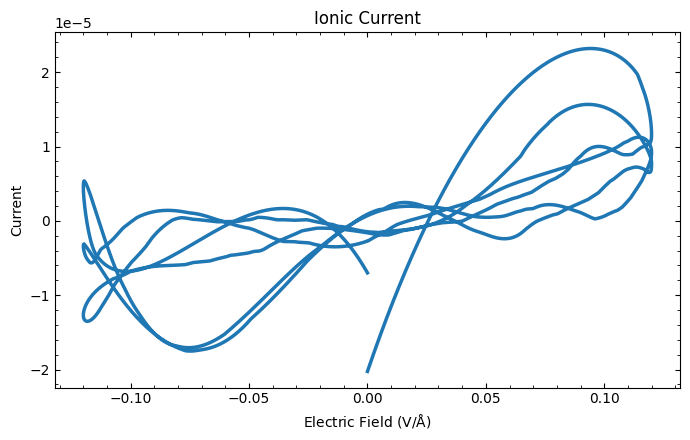

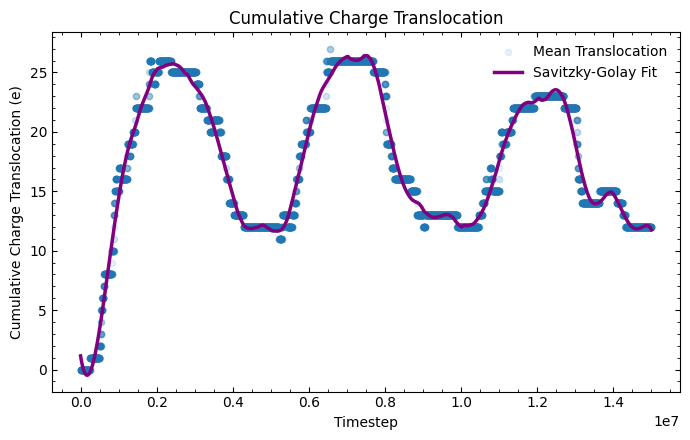

In [13]:
plot_current(ionic_current)
plot_current_vs_field(ionic_current, log_df)
plot_cumulative_charge_translocation(ionic_current)

In [ ]:
from MDToolkit.IO.write_file import export_numeric_data
from pathlib import Path

v_idxs = np.searchsorted(np.array(log_df["Step"]), np.array(ionic_current["timesteps"]))

data = {"timesteps" : ionic_current["timesteps"],
        "V" : np.array(log_df["v_ef_x"])[v_idxs],
        f"charge_translocation" : ionic_current["cumulative_charge_translocation"]}

export_numeric_data(data, f"kcl_mos2_ensemble{ensemble}_{max(times)}ns.csv", Path(file_root_dir))

CSV file written to: /media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/kcl_mos2_ensemble10_15ns.csv
